In [1]:
import numpy as np
import pandas as pd

from raas.neural_policy import DPAgent
# from raas.discrete_policy import DiscretizedDPAgent
from raas.optimized_discrete_policy import DiscretizedDPAgent
from raas.simulation import Simulator, CustomerGenerator
from raas.hazard_models import ExponentialHazard
from raas.utility_learner import ProjectedVolumeLearner
from raas.degradation_learner import DegradationLearner
from datetime import datetime
from pytz import timezone

import matplotlib.pyplot as plt

import logging
logging.basicConfig(level=logging.INFO)

from raas.config import (
    context_sampler,
    rental_sampler,
    interarrival_sampler,
    
    D,
    LAMBDA_VAL,
    NUM_CUSTOMERS,
    THETA_TRUE,
    UTILITY_TRUE,
    PRICING_R,
    
    centroid_params,
    termination_rule,
    
    mdp_params,
    training_hyperparams,
    incentive_constant,
    
    policy_type,
    policy_kwargs,
)

np.set_printoptions(suppress=True)

In [2]:
usage_exp_hazard_model = ExponentialHazard(lambda_val=LAMBDA_VAL)

customer_gen = CustomerGenerator(
    d=D,
    context_sampler=context_sampler,
    rental_sampler=rental_sampler,
    interarrival_sampler=interarrival_sampler
)

projected_volume_learner = ProjectedVolumeLearner(
    T=NUM_CUSTOMERS, 
    d=D, 
    centroid_params=centroid_params,
    incentive_constant=incentive_constant,
    termination_rule=termination_rule,
)

# Instantiate the Simulator with the new parameters
simulator = Simulator(
    d=D,
    T=NUM_CUSTOMERS,
    
    theta_true=THETA_TRUE,
    utility_true=UTILITY_TRUE,
    pricing_r=PRICING_R,
    
    usage_hazard_model=usage_exp_hazard_model,
    customer_generator=customer_gen,
    projected_volume_learner=projected_volume_learner,  # Use default ProjectedVolumeLearner
    
    mdp_params=mdp_params,
    discrete_dp=True,
    policy_type=policy_type,
    training_hyperparams=training_hyperparams,
    policy_kwargs=policy_kwargs,
    policy_update_threshold=100,
    time_normalize=True,
)

In [3]:
# # Lets you skip utility exploration with perfect u starting point
simulator.projected_volume_learner.centroids.append(UTILITY_TRUE)
simulator.projected_volume_learner.is_terminated = True
simulator.seen_breakdowns = 2

degradation_learner = DegradationLearner(d=simulator.d)
degradation_learner.theta = np.ones(D) * 0.1
degradation_learner.cum_baseline = lambda x: LAMBDA_VAL * x
degradation_learner.inverse_cum_baseline = lambda y: y / LAMBDA_VAL
simulator.degradation_learner = degradation_learner



# dp_agent = DPAgent(
#     d=simulator.d,
#     u_hat=UTILITY_TRUE,
#     time_normalize=simulator.time_normalize,
#     degradation_learner=simulator.degradation_learner,
#     customer_generator=simulator.customer_generator,
#     params=simulator.mdp_params
# )
# dp_agent.train(**simulator.training_hyperparams)

dp_agent = DiscretizedDPAgent(
    N=training_hyperparams['N'], # grid sizes [cum_context, context, duration, active_time]
    max_cumulative_context=training_hyperparams['max_cumulative_context'],
    # max_active_time=training_hyperparams['max_active_time'],
    u_hat=UTILITY_TRUE,
    degradation_learner=degradation_learner,
    customer_generator=customer_gen,
    params=mdp_params,
)


# dp_agent._precompute_dynamics(num_samples=50000)
dp_agent.run_value_iteration(100)

simulator.dp_agent = dp_agent
simulator.optimal_policy = dp_agent.get_policy(simulator.policy_type)
simulator.breakdowns_since_last_update = 0 # Reset the counter


INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        50 steps up to 8.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 0.76
INFO:root:  - Active Time (t)                50 steps up to 7.60
INFO:root:Pre-computing dynamics (50x50x50x50 = 6,250,000 4D states, vs 312,500,000 original 5D)...
INFO:root:  Sampling 100000 customers for expectation weights...
INFO:root:  4318 unique customer tuples (from 100000 samples)
INFO:root:  Computing Delta_Lambda (2D)...
INFO:root:  Computing P_survival (4D)...
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
INFO:root:  Computing next-state indices (2D)...
INFO:root:Pre-computation complete.
INFO:root:
Starting Value Iteration (optimized) — 312,500,000 states, float32, fused kernel...
INFO:root:Iteration 10/100 | Max Delta: 0.4

In [4]:
pacific_tz = timezone('America/Los_Angeles')
current_time = datetime.now(pacific_tz).strftime("%Y%m%d_%H%M%S")

# simulator.projected_volume_learner.is_terminated = True
simulation_data = simulator.run(num_customers=NUM_CUSTOMERS)
degradation_df = pd.DataFrame(simulator.degradation_history)
simulation_df = pd.DataFrame(simulator.history)

degradation_df.to_csv(f'data/degradation_data_{current_time}.csv', index=False)
simulation_df.to_csv(f'data/simulation_data_{current_time}.csv', index=False)
simulator.save(f'models/simulator_{current_time}')

INFO:root:Starting simulation for 40000 customers...
  0%|          | 0/40000 [00:00<?, ?it/s]INFO:root:Updating optimal policy...


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         4 variables are exactly at the bounds

At iterate    0    f=  3.70566D+02    |proj g|=  1.00000D+00

At iterate    1    f=  3.30358D+02    |proj g|=  5.97329D-01

At iterate    2    f=  3.29533D+02    |proj g|=  5.17690D-01

At iterate    3    f=  3.28656D+02    |proj g|=  2.33564D-01


INFO:root:Theta updated. New theta_hat: [0.36  0.238 0.405 0.673]
INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        50 steps up to 8.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 0.76
INFO:root:  - Active Time (t)                50 steps up to 7.60
INFO:root:Pre-computing dynamics (50x50x50x50 = 6,250,000 4D states, vs 312,500,000 original 5D)...
INFO:root:  Sampling 100000 customers for expectation weights...



At iterate    4    f=  3.28654D+02    |proj g|=  4.29237D-02

At iterate    5    f=  3.28654D+02    |proj g|=  2.41519D-03

At iterate    6    f=  3.28654D+02    |proj g|=  2.19958D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4      6      8      9     0     0   2.200D-04   3.287D+02
  F =   328.65411645637198     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


INFO:root:  5297 unique customer tuples (from 100000 samples)
INFO:root:  Computing Delta_Lambda (2D)...
INFO:root:  Computing P_survival (4D)...
INFO:root:  Computing next-state indices (2D)...
INFO:root:Pre-computation complete.
INFO:root:
Starting Value Iteration (optimized) — 312,500,000 states, float32, fused kernel...
INFO:root:Iteration 10/100 | Max Delta: 0.398515
INFO:root:Iteration 20/100 | Max Delta: 0.305407
INFO:root:Iteration 30/100 | Max Delta: 0.236614
INFO:root:Iteration 40/100 | Max Delta: 0.184649
INFO:root:Iteration 50/100 | Max Delta: 0.145197
INFO:root:Iteration 60/100 | Max Delta: 0.115409
INFO:root:Iteration 70/100 | Max Delta: 0.092393
INFO:root:Iteration 80/100 | Max Delta: 0.074415
INFO:root:Iteration 90/100 | Max Delta: 0.060165
INFO:root:Iteration 100/100 | Max Delta: 0.048827
INFO:root:
Value iteration finished (max iterations reached).
INFO:root:Computing final policies...
INFO:root:Policies computed.
INFO:root:Policy updated.
  2%|▏         | 868/40000 [

...

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         4 variables are exactly at the bounds

At iterate    0    f=  5.31895D+03    |proj g|=  1.00000D+00

At iterate    1    f=  4.98015D+03    |proj g|=  6.77666D-01

At iterate    2    f=  4.97531D+03    |proj g|=  6.14946D-01

At iterate    3    f=  4.97093D+03    |proj g|=  5.12445D-01

At iterate    4    f=  4.97025D+03    |proj g|=  4.64894D-01

At iterate    5    f=  4.97025D+03    |proj g|=  2.01117D-01

At iterate    6    f=  4.97025D+03    |proj g|=  1.88537D-01

At iterate    7    f=  4.97025D+03    |proj g|=  4.91618D-02

At iterate    8    f=  4.97025D+03    |proj g|=  1.84551D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg 

INFO:root:Theta updated. New theta_hat: [0.522 0.211 0.342 0.313]
INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        50 steps up to 8.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 0.76
INFO:root:  - Active Time (t)                50 steps up to 7.60
INFO:root:Pre-computing dynamics (50x50x50x50 = 6,250,000 4D states, vs 312,500,000 original 5D)...
INFO:root:  Sampling 100000 customers for expectation weights...
INFO:root:  6723 unique customer tuples (from 100000 samples)
INFO:root:  Computing Delta_Lambda (2D)...
 17%|█▋        | 6868/40000 [02:20<10:59, 50.23it/s]INFO:root:  Computing P_survival (4D)...
INFO:root:  Computing next-state indices (2D)...
INFO:root:Pre-computation complete.
INFO:root:
Starting Value Iteration (optimized) — 312,500,000 states, float32, fused kernel...
INFO:root:Iteration 10

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         4 variables are exactly at the bounds

At iterate    0    f=  6.02001D+03    |proj g|=  1.00000D+00

At iterate    1    f=  5.64926D+03    |proj g|=  6.82095D-01

At iterate    2    f=  5.64285D+03    |proj g|=  6.57133D-01

At iterate    3    f=  5.63630D+03    |proj g|=  4.84005D-01

At iterate    4    f=  5.63551D+03    |proj g|=  5.34117D-01

At iterate    5    f=  5.63550D+03    |proj g|=  2.57826D-01

At iterate    6    f=  5.63550D+03    |proj g|=  2.32021D-01

At iterate    7    f=  5.63550D+03    |proj g|=  3.25026D-02

At iterate    8    f=  5.63550D+03    |proj g|=  2.37261D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg 

INFO:root:Theta updated. New theta_hat: [0.553 0.22  0.339 0.26 ]
INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        50 steps up to 8.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 0.76
INFO:root:  - Active Time (t)                50 steps up to 7.60
INFO:root:Pre-computing dynamics (50x50x50x50 = 6,250,000 4D states, vs 312,500,000 original 5D)...
INFO:root:  Sampling 100000 customers for expectation weights...
 21%|██▏       | 8557/40000 [02:34<09:28, 55.33it/s]


KeyboardInterrupt: 

In [6]:
degradation_df = pd.DataFrame(simulator.degradation_history)
simulation_df = pd.DataFrame(simulator.history)

degradation_df.to_csv(f'../data/degradation_data_{current_time}.csv', index=False)
simulation_df.to_csv(f'../data/simulation_data_{current_time}.csv', index=False)
simulator.save(f'../models/simulator_{current_time}')

INFO:root:Policy saved to ../models/simulator_20260209_185719.discrete_policy.pkl
INFO:root:Simulation state saved to ../models/simulator_20260209_185719.


### Convergence of $\hat\theta$

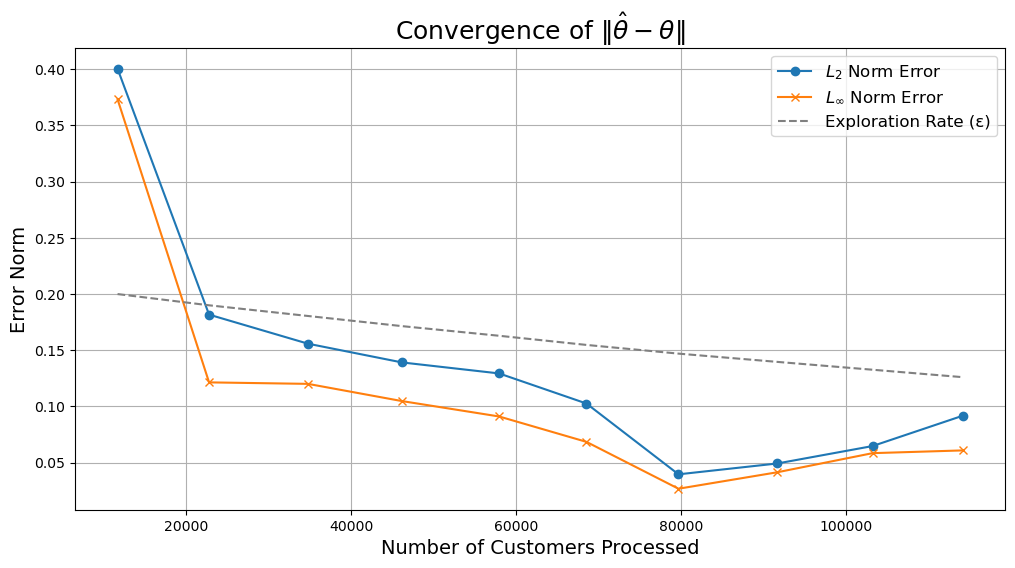

In [8]:
# simulator = Simulator.load('models/simulator_0914')

history = pd.DataFrame(simulator.history)
degradation_history = pd.DataFrame(simulator.degradation_history)

epsilons = [0.20 * (0.95 ** i) for i in range(len(simulator.theta_updates))]

times = []

for d in simulator.theta_updates:
    idx, theta_hat = d['customer_idx'], d['theta_hat']
    time = history[history.customer_id == idx]['calendar_time'].max()
    times.append(time)
    
# plot L2, and L-inf norms of utility updates
L2_errors = [np.linalg.norm(update['theta_hat'] - THETA_TRUE) for update in simulator.theta_updates]
Linf_errors = [np.linalg.norm(update['theta_hat'] - THETA_TRUE, ord=np.inf) for update in simulator.theta_updates]

plt.figure(figsize=(12, 6))
plt.plot(times, L2_errors, label='$L_2$ Norm Error', marker='o')
plt.plot(times, Linf_errors, label='$L_\infty$ Norm Error', marker='x')
plt.plot(times, epsilons, label='Exploration Rate (ε)', linestyle='--', color='gray')
# plt.yscale('log')
plt.xlabel('Number of Customers Processed', fontsize=14)
plt.ylabel('Error Norm', fontsize=14)

plt.title('Convergence of $\|\hat{\\theta} - \\theta\|$', fontsize=18)
plt.legend(fontsize=12)
plt.grid(True)
# plt.savefig('../figures/utility_convergence.pdf')
plt.show()

### Convergence of $\hat u$

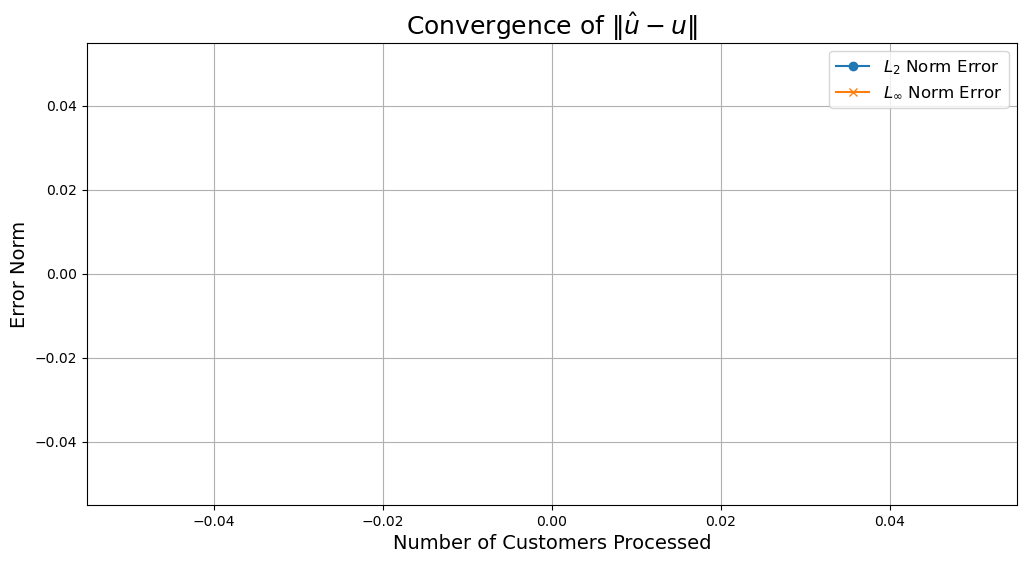

In [9]:
simulator.utility_updates

# plot L2, and L-inf norms of utility updates
L2_errors = [np.linalg.norm(update['u_hat'] - UTILITY_TRUE) for update in simulator.utility_updates]
Linf_errors = [np.linalg.norm(update['u_hat'] - UTILITY_TRUE, ord=np.inf) for update in simulator.utility_updates]

plt.figure(figsize=(12, 6))
plt.plot(L2_errors, label='$L_2$ Norm Error', marker='o')
plt.plot(Linf_errors, label='$L_\infty$ Norm Error', marker='x')
# plt.yscale('log')
plt.xlabel('Number of Customers Processed', fontsize=14)
plt.ylabel('Error Norm', fontsize=14)

plt.title('Convergence of $\|\hat u - u\|$', fontsize=18)
plt.legend(fontsize=12)
plt.grid(True)
# plt.savefig('../figures/utility_convergence.pdf')
plt.show()

### Revenue of Online Learner

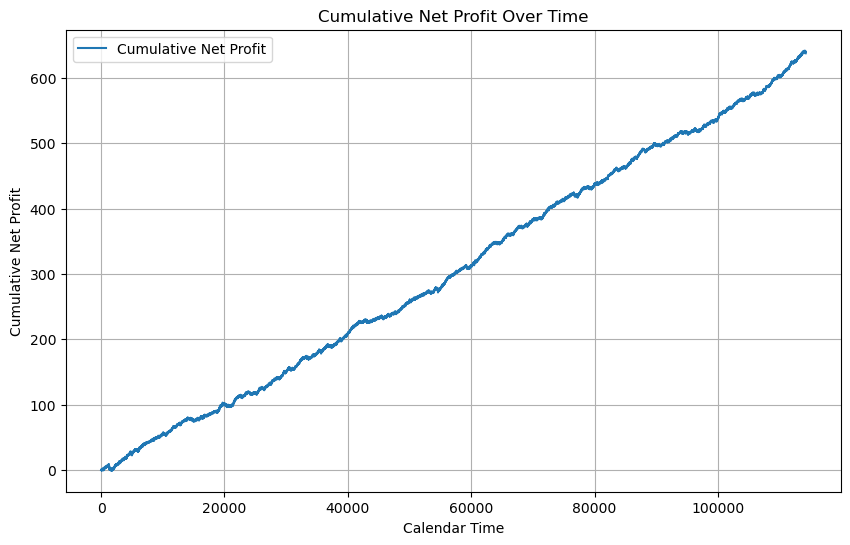

In [10]:
degradation_df = pd.DataFrame(simulator.degradation_history)
simulation_df = pd.DataFrame(simulator.history)

simulation_df['net_profit'] = simulation_df['profit'] + simulation_df['loss']
simulation_df['cumulative_net_profit'] = simulation_df['net_profit'].cumsum()

ax = plt.figure(figsize=(10,6))

# plot cumulative profit and loss over time
plt.plot(simulation_df['calendar_time'], simulation_df['cumulative_net_profit'], label='Cumulative Net Profit')
plt.xlabel('Calendar Time')
plt.ylabel('Cumulative Net Profit')
plt.title('Cumulative Net Profit Over Time')
plt.legend()
plt.grid()
plt.savefig('../figures/cumulative_net_profit_online.pdf')
plt.show()

## Training policy under perfect information

### Revenue of Optimal Policy

In [11]:
class PerfectDegradationLearner:
    def __init__(self, d, theta_true, hazard_model):
        self.d = d
        self.theta_true = theta_true
        self.hazard_model = hazard_model  # Placeholder, not used
        
    def get_theta(self):
        return self.theta_true
    
    def cum_baseline(self, t):
        return self.hazard_model.Lambda_0(t)
    
    def inverse_cum_baseline(self, u):
        return self.hazard_model.Lambda_0_inverse(u)
    
perfect_degradation_learner = PerfectDegradationLearner(
    d=D, 
    theta_true=THETA_TRUE,
    hazard_model=usage_exp_hazard_model,
)

# N_perfect = [100, 40, 80, 150]

perfect_dpagent = DiscretizedDPAgent(
    N=simulator.training_hyperparams['N'], # grid sizes [cum_context, context, duration, active_time]
    max_cumulative_context=simulator.training_hyperparams['max_cumulative_context'],
    # max_active_time=simulator.training_hyperparams['max_active_time'],
    u_hat=UTILITY_TRUE,
    degradation_learner=perfect_degradation_learner,
    customer_generator=customer_gen,
    params=simulator.mdp_params,
)
# perfect_dpagent.run_value_iteration(simulator.training_hyperparams['num_value_iterations'])

# weight = torch.load('weights/perfect_dpagent_q_network.pth', map_location=torch.device('cuda'))
# perfect_dpagent.q_network.load_state_dict(weight)
# perfect_dpagent.q_network.to(perfect_dpagent.device)
# perfect_dpagent.q_network.eval()
perfect_dpagent._precompute_dynamics(100000)
perfect_dpagent.run_value_iteration(150)
perfect_policy = perfect_dpagent.get_policy('greedy')

INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        50 steps up to 8.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 0.76
INFO:root:  - Active Time (t)                50 steps up to 7.60
INFO:root:Pre-computing dynamics (50x50x50x50 = 6,250,000 4D states, vs 312,500,000 original 5D)...
INFO:root:  Sampling 100000 customers for expectation weights...
INFO:root:  6796 unique customer tuples (from 100000 samples)
INFO:root:  Computing Delta_Lambda (2D)...
INFO:root:  Computing P_survival (4D)...
INFO:root:  Computing next-state indices (2D)...
INFO:root:Pre-computation complete.
INFO:root:Pre-computing dynamics (50x50x50x50 = 6,250,000 4D states, vs 312,500,000 original 5D)...
INFO:root:  Sampling 100000 customers for expectation weights...
INFO:root:  6646 unique customer tuples (from 100000 samples)
INFO:roo

In [12]:
simulation_df = pd.DataFrame(simulator.history)
# simulator.degradation_learner = perfect_degradation_learner
samples = simulator.run_full_exploit(
    100000, 
    perfect_policy, 
    perfect_degradation_learner,
    {'tau': 0.01}
)
samples = pd.DataFrame(samples)

simulation_df['net_profit'] = simulation_df['profit'] + simulation_df['loss']
simulation_df['cumulative_net_profit'] = simulation_df['net_profit'].cumsum()
samples['net_profit'] = samples['profit'] + samples['loss']
samples['cumulative_net_profit'] = samples['net_profit'].cumsum()

samples['netprofit_per_time'] = samples['cumulative_net_profit'] / samples['calendar_time']
simulation_df['netprofit_per_time'] = simulation_df['cumulative_net_profit'] / simulation_df['calendar_time']

INFO:root:Starting simulation for 100000 customers...
100%|██████████| 100000/100000 [00:02<00:00, 33997.43it/s]
INFO:root:Simulation finished.


In [13]:
def calculate_rolling_rate(df, time_col, value_col, window_size):
    """
    Calculates the rate of a value over a rolling time window on irregular time series data.

    Args:
        df (pd.DataFrame): The input dataframe.
        time_col (str): The name of the column with time data.
        value_col (str): The name of the column with values to aggregate (e.g., 'net_profit').
        window_size (int): The duration of the rolling time window.

    Returns:
        pd.Series: A series containing the calculated rolling rate for each row.
    """
    # Ensure the dataframe is sorted by time, which is crucial.
    df = df.sort_values(time_col).reset_index(drop=True)
    
    times = df[time_col].values
    values = df[value_col].values
    
    # For each end time `t_i`, find the start time `t_i - window`.
    start_times = times - window_size
    
    # Use searchsorted to find the index where each start_time would be inserted.
    # This gives us the starting index of each time window efficiently.
    start_indices = np.searchsorted(times, start_times, side='left')
    
    # Use a cumulative sum to efficiently calculate the sum over any slice [j, i].
    value_cumsum = np.cumsum(values)
    
    # The sum for a window ending at `i` is cumsum[i] - cumsum[start_index - 1].
    # We create a shifted cumulative sum array to handle the `start_index - 1` lookup.
    shifted_cumsum = np.concatenate(([0], value_cumsum[:-1]))
    
    # Calculate the sum of values within each rolling window.
    window_sums = value_cumsum - shifted_cumsum[start_indices]
    
    # The rate is the sum of profit in the window divided by the window's duration.
    profit_rate = window_sums / window_size
    
    return pd.Series(profit_rate, index=df.index)


# --- 2. Calculate net profit and the rolling rate for each DataFrame ---

window_duration = 20000 # Define the time window for the rolling rate

for df in [simulation_df]:
# for df in [samples]:
    df['net_profit'] = df['profit'] + df['loss']
    # Add the new 'profit_rate' column using our helper function
    df['profit_rate'] = calculate_rolling_rate(df, 'calendar_time', 'net_profit', window_duration)

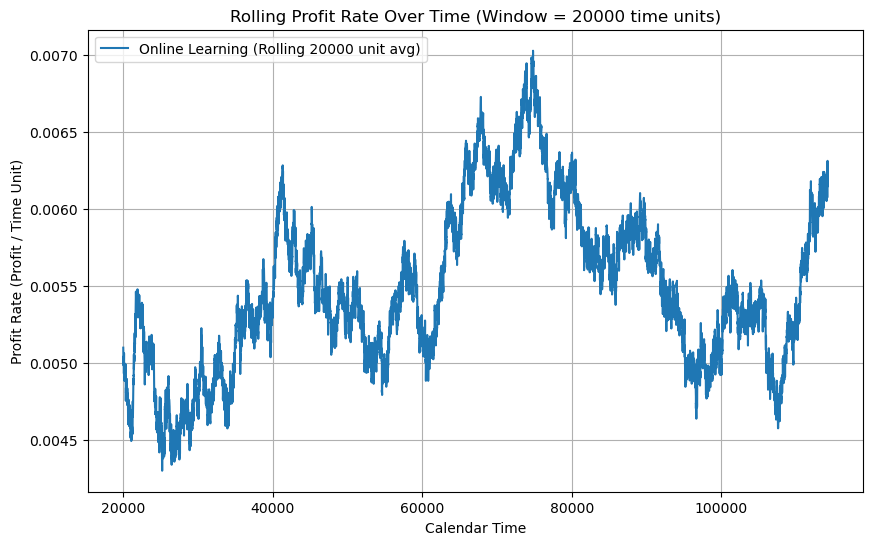

In [14]:
# --- 3. Plot the new rolling profit rate ---

# max_time = min(simulation_df['calendar_time'].max(), samples['calendar_time'].max())
max_time = simulation_df['calendar_time'].max()
# samples_plot = samples[(window_duration <= samples['calendar_time']) & (samples['calendar_time'] <= max_time)]
simulations_plot = simulation_df[
    (window_duration <= simulation_df['calendar_time']) &
    (simulation_df['calendar_time'] <= max_time)]


plt.figure(figsize=(10, 6))

# plt.plot(samples_plot['calendar_time'], samples_plot['profit_rate'], label=f'Optimal Policy (Rolling {window_duration} unit avg)')
plt.plot(simulations_plot['calendar_time'], simulations_plot['profit_rate'], label=f'Online Learning (Rolling {window_duration} unit avg)')

plt.xlabel('Calendar Time')
plt.ylabel('Profit Rate (Profit / Time Unit)')
plt.title(f'Rolling Profit Rate Over Time (Window = {window_duration} time units)')
plt.legend()
plt.grid(True)
plt.show()